# MCDI500 — Programación para la Ciencia de Datos
## Fase 2: Obtención, limpieza y transformación de datos

**Proyecto:** PROYECTO-GRUPO4-MCDI500  
**Integrantes:**
- Carolina Cortés Donoso
- Pedro Espinoza Vicentela
- Marcelo Corro Troncoso
- Juan Pablo Valdebenito Loyola

**Docente:** Omar Iván Salinas Silva  
**Fecha:** Junio 2026

---
## 1. Introducción

Esta fase corresponde al pipeline de obtención, limpieza y transformación del dataset **Breast Cancer Wisconsin (Diagnostic)**. El objetivo es preparar los datos de forma rigurosa y reproducible para su uso en la etapa de modelado (Fase 3).

### Objetivos de la Fase 2
1. Cargar el dataset desde `data/raw/` de forma estructurada.
2. Realizar un diagnóstico completo: dimensiones, tipos de datos, valores faltantes y duplicados.
3. Ejecutar el pipeline de limpieza estándar y documentar los hallazgos.
4. Aplicar las transformaciones necesarias para el modelado.
5. Validar la integridad y consistencia del dataset procesado.
6. Exportar el dataset limpio a `data/processed/`.

### Estructura del pipeline
```
data/raw/wdbc.data
    └── cargar_datos()
        └── explorar_datos()
            └── limpiar_datos()
                └── transformar_datos()
                    └── validar_dataset()
                        └── data/processed/wdbc_procesado.csv
```

---
## 2. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display
from sklearn.preprocessing import StandardScaler

# Rutas base del proyecto
RUTA_RAW = Path('../../data/raw/wdbc.data')
RUTA_PROCESSED = Path('../../data/processed/wdbc_procesado.csv')

# Nombres de columnas segun wdbc.names
COLUMNAS = [
    'id', 'diagnostico',
    'radio_mean', 'textura_mean', 'perimetro_mean', 'area_mean',
    'suavidad_mean', 'compacidad_mean', 'concavidad_mean', 'puntos_concavos_mean',
    'simetria_mean', 'dimension_fractal_mean',
    'radio_se', 'textura_se', 'perimetro_se', 'area_se',
    'suavidad_se', 'compacidad_se', 'concavidad_se', 'puntos_concavos_se',
    'simetria_se', 'dimension_fractal_se',
    'radio_worst', 'textura_worst', 'perimetro_worst', 'area_worst',
    'suavidad_worst', 'compacidad_worst', 'concavidad_worst', 'puntos_concavos_worst',
    'simetria_worst', 'dimension_fractal_worst'
]

print('Librerias importadas correctamente.')

Librerias importadas correctamente.


---
## 3. Carga del dataset

Se carga el dataset desde `data/raw/` sin modificar el archivo original. La función `cargar_datos()` encapsula esta responsabilidad y devuelve un DataFrame con los nombres de columna correctamente asignados.

In [2]:
def cargar_datos(ruta: Path, columnas: list) -> pd.DataFrame:
    """
    Carga el dataset crudo desde la ruta especificada.

    Parametros:
        ruta (Path): ruta al archivo .data original.
        columnas (list): lista de nombres de columnas.

    Retorna:
        pd.DataFrame: dataset cargado con columnas nombradas.
    """
    df = pd.read_csv(ruta, header=None, names=columnas)
    print(f'Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas.')
    return df


df_raw = cargar_datos(RUTA_RAW, COLUMNAS)

Dataset cargado: 569 filas, 32 columnas.


---
## 4. Exploración inicial del dataset

Antes de aplicar cualquier transformación, se realiza un diagnóstico completo del dataset. Esta etapa permite tomar decisiones informadas sobre la estrategia de limpieza y transformación.

In [3]:
def explorar_datos(df: pd.DataFrame) -> dict:
    """
    Realiza un diagnostico completo del dataset.

    Parametros:
        df (pd.DataFrame): dataset a explorar.

    Retorna:
        dict: resumen con metricas clave del diagnostico.
    """
    print('=' * 55)
    print('DIAGNOSTICO DEL DATASET')
    print('=' * 55)
    print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
    print('\n--- Tipos de datos ---')
    print(df.dtypes)
    print('\n--- Primeras 5 filas ---')
    display(df.head())
    print('\n--- Valores faltantes por columna ---')
    na_counts = df.isnull().sum()
    total_na = na_counts.sum()
    print(na_counts[na_counts > 0] if total_na > 0 else 'No se encontraron valores faltantes.')
    print(f'Total de valores faltantes: {total_na}')
    print('\n--- Filas duplicadas ---')
    total_dup = df.duplicated().sum()
    print(f'Total de filas duplicadas: {total_dup}')
    print('\n--- Distribucion de la variable objetivo ---')
    dist = df['diagnostico'].value_counts()
    print(dist)
    print(f'Benignos (B): {dist.get("B", 0)} | Malignos (M): {dist.get("M", 0)}')
    print('\n--- Estadisticas descriptivas ---')
    display(df.describe().T)
    return {'filas': df.shape[0], 'columnas': df.shape[1], 'total_na': total_na, 'total_duplicados': total_dup}


diagnostico = explorar_datos(df_raw)

DIAGNOSTICO DEL DATASET
Dimensiones: 569 filas x 32 columnas

--- Tipos de datos ---
id                           int64
diagnostico                    str
radio_mean                 float64
textura_mean               float64
perimetro_mean             float64
area_mean                  float64
suavidad_mean              float64
compacidad_mean            float64
concavidad_mean            float64
puntos_concavos_mean       float64
simetria_mean              float64
dimension_fractal_mean     float64
radio_se                   float64
textura_se                 float64
perimetro_se               float64
area_se                    float64
suavidad_se                float64
compacidad_se              float64
concavidad_se              float64
puntos_concavos_se         float64
simetria_se                float64
dimension_fractal_se       float64
radio_worst                float64
textura_worst              float64
perimetro_worst            float64
area_worst                 float64
suavi

,id,diagnostico,radio_mean,textura_mean,perimetro_mean,area_mean,suavidad_mean,compacidad_mean,concavidad_mean,puntos_concavos_mean,...,radio_worst,textura_worst,perimetro_worst,area_worst,suavidad_worst,compacidad_worst,concavidad_worst,puntos_concavos_worst,simetria_worst,dimension_fractal_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



--- Valores faltantes por columna ---
No se encontraron valores faltantes.
Total de valores faltantes: 0

--- Filas duplicadas ---
Total de filas duplicadas: 0

--- Distribucion de la variable objetivo ---
diagnostico
B    357
M    212
Name: count, dtype: int64
Benignos (B): 357 | Malignos (M): 212

--- Estadisticas descriptivas ---


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radio_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
textura_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimetro_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
suavidad_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compacidad_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavidad_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
puntos_concavos_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
simetria_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


---
## 5. Limpieza del dataset

### Estrategia de limpieza

El diagnóstico anterior confirmó que el dataset **no contiene valores faltantes ni filas duplicadas**. Sin embargo, el pipeline de limpieza se ejecuta de todas formas, ya que forma parte del proceso estándar de preparación de datos. Esto garantiza que el pipeline sea robusto y reutilizable ante cualquier versión futura del dataset que pudiera presentar estos problemas.

Adicionalmente, se elimina la columna `id`, que corresponde a un identificador de paciente sin valor predictivo para el modelo de clasificación.

In [4]:
def limpiar_datos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ejecuta el pipeline estandar de limpieza del dataset.

    Operaciones:
        - Elimina la columna 'id' (sin valor predictivo).
        - Elimina filas duplicadas si las hubiera.
        - Imputa NA en variables numericas con la mediana si los hubiera.

    Parametros:
        df (pd.DataFrame): dataset crudo.

    Retorna:
        pd.DataFrame: dataset limpio (copia, sin modificar el original).
    """
    df_limpio = df.copy()

    # 1. Eliminar columna 'id' (identificador sin valor predictivo)
    df_limpio = df_limpio.drop(columns=['id'])
    print(f'Columna id eliminada. Columnas restantes: {df_limpio.shape[1]}')

    # 2. Eliminar filas duplicadas
    filas_antes = len(df_limpio)
    df_limpio = df_limpio.drop_duplicates()
    print(f'Filas duplicadas eliminadas: {filas_antes - len(df_limpio)}')

    # 3. Imputar NA en variables numericas con la mediana
    columnas_num = df_limpio.select_dtypes(include='number').columns
    na_antes = df_limpio[columnas_num].isnull().sum().sum()
    for col in columnas_num:
        if df_limpio[col].isnull().any():
            df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())
    na_despues = df_limpio[columnas_num].isnull().sum().sum()
    print(f'Valores NA imputados: {na_antes - na_despues} (antes: {na_antes}, despues: {na_despues})')

    print(f'Dataset limpio: {df_limpio.shape[0]} filas x {df_limpio.shape[1]} columnas.')
    return df_limpio


df_limpio = limpiar_datos(df_raw)

Columna id eliminada. Columnas restantes: 31
Filas duplicadas eliminadas: 0
Valores NA imputados: 0 (antes: 0, despues: 0)
Dataset limpio: 569 filas x 31 columnas.


---
## 6. Transformación del dataset

Se aplican las transformaciones necesarias para dejar el dataset listo para el modelado de la Fase 3.

### Transformaciones aplicadas

| Transformación | Variable(s) | Justificación |
|---|---|---|
| Codificación binaria | `diagnostico` | Convierte B→0 y M→1 para compatibilidad con los modelos de clasificación supervisada. |
| Estandarización (StandardScaler) | 30 variables morfológicas | Las variables tienen escalas muy distintas (radio ~14, área ~654). La estandarización centra en 0 y escala a desviación estándar 1, evitando que variables de mayor magnitud dominen el modelo. |

In [5]:
def transformar_datos(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aplica las transformaciones necesarias para el modelado.

    Operaciones:
        - Codifica 'diagnostico': B->0, M->1.
        - Estandariza las 30 variables morfologicas con StandardScaler.

    Parametros:
        df (pd.DataFrame): dataset limpio.

    Retorna:
        pd.DataFrame: dataset transformado listo para modelado.
    """
    df_t = df.copy()

    # 1. Codificacion binaria de la variable objetivo
    df_t['diagnostico'] = df_t['diagnostico'].map({'B': 0, 'M': 1})
    print('Variable objetivo codificada: B->0, M->1')
    print(df_t['diagnostico'].value_counts().rename({0: 'Benigno (0)', 1: 'Maligno (1)'}), '\n')

    # 2. Estandarizacion de variables numericas (excluye 'diagnostico')
    cols_num = df_t.select_dtypes(include='number').columns.tolist()
    cols_num.remove('diagnostico')
    scaler = StandardScaler()
    df_t[cols_num] = scaler.fit_transform(df_t[cols_num])
    print(f'Variables estandarizadas: {len(cols_num)}')
    print('Verificacion post-estandarizacion (media ~ 0, std ~ 1):')
    display(df_t[cols_num].describe().loc[['mean', 'std']].T.round(4).head(5))

    return df_t


df_transformado = transformar_datos(df_limpio)

Variable objetivo codificada: B->0, M->1
diagnostico
Benigno (0)    357
Maligno (1)    212
Name: count, dtype: int64 

Variables estandarizadas: 30
Verificacion post-estandarizacion (media ~ 0, std ~ 1):


,mean,std
radio_mean,-0.0,1.0009
textura_mean,0.0,1.0009
perimetro_mean,-0.0,1.0009
area_mean,-0.0,1.0009
suavidad_mean,-0.0,1.0009


---
## 7. Visualizaciones del dataset procesado

Se generan visualizaciones para verificar visualmente el resultado de las transformaciones aplicadas.

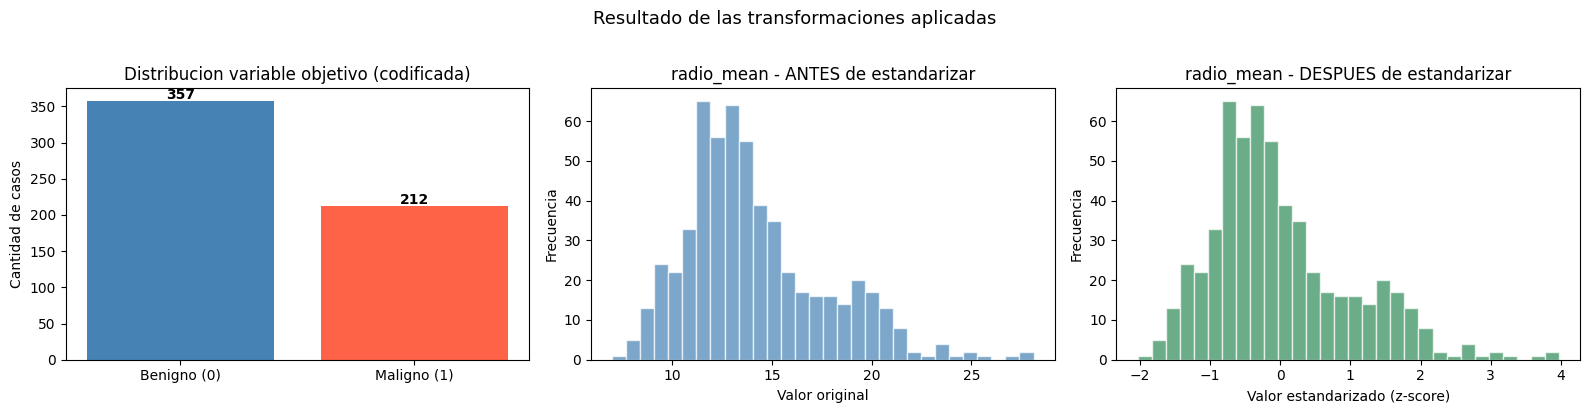

In [6]:
def visualizar_transformaciones(df_original: pd.DataFrame, df_transformado: pd.DataFrame) -> None:
    """
    Genera visualizaciones comparativas antes y despues de la estandarizacion.

    Parametros:
        df_original (pd.DataFrame): dataset limpio antes de transformar.
        df_transformado (pd.DataFrame): dataset despues de transformar.
    """
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Distribucion variable objetivo codificada
    conteo = df_transformado['diagnostico'].value_counts().sort_index()
    axes[0].bar(['Benigno (0)', 'Maligno (1)'], conteo.values, color=['steelblue', 'tomato'])
    for i, v in enumerate(conteo.values):
        axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')
    axes[0].set_title('Distribucion variable objetivo (codificada)')
    axes[0].set_ylabel('Cantidad de casos')

    # radio_mean antes
    axes[1].hist(df_original['radio_mean'], bins=30, color='steelblue', alpha=0.7, edgecolor='white')
    axes[1].set_title('radio_mean - ANTES de estandarizar')
    axes[1].set_xlabel('Valor original')
    axes[1].set_ylabel('Frecuencia')

    # radio_mean despues
    axes[2].hist(df_transformado['radio_mean'], bins=30, color='seagreen', alpha=0.7, edgecolor='white')
    axes[2].set_title('radio_mean - DESPUES de estandarizar')
    axes[2].set_xlabel('Valor estandarizado (z-score)')
    axes[2].set_ylabel('Frecuencia')

    plt.suptitle('Resultado de las transformaciones aplicadas', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


visualizar_transformaciones(df_limpio, df_transformado)

---
## 8. Validación del dataset procesado

Se ejecutan validaciones formales para garantizar la integridad y consistencia del dataset.

**Nota técnica:** `StandardScaler` utiliza la desviación estándar poblacional (`ddof=0`). Por ello, la verificación también usa `ddof=0` para mantener consistencia con el escalador aplicado.

In [7]:
def validar_dataset(df: pd.DataFrame) -> None:
    """
    Valida la integridad y consistencia del dataset procesado
    mediante assertions y resumen de metricas finales.

    Parametros:
        df (pd.DataFrame): dataset transformado a validar.

    Lanza:
        AssertionError: si alguna condicion de integridad no se cumple.
    """
    print('=' * 55)
    print('VALIDACION DEL DATASET PROCESADO')
    print('=' * 55)

    # 1. Sin valores NA
    assert df.isnull().sum().sum() == 0, 'ERROR: El dataset contiene valores NA.'
    print('OK: Sin valores NA.')

    # 2. Sin filas duplicadas
    assert not df.duplicated().any(), 'ERROR: El dataset contiene filas duplicadas.'
    print('OK: Sin filas duplicadas.')

    # 3. Variable objetivo solo contiene 0 y 1
    assert set(df['diagnostico'].unique()).issubset({0, 1}), 'ERROR: Variable objetivo con valores inesperados.'
    print('OK: Variable objetivo correctamente codificada:', sorted(df['diagnostico'].unique()))

    # 4. Variables numericas estandarizadas (media ~ 0, std ~ 1)
    # StandardScaler usa ddof=0, verificamos con ddof=0 para consistencia.
    cols_num = df.select_dtypes(include='number').columns.tolist()
    cols_num.remove('diagnostico')
    medias = df[cols_num].mean()
    desviaciones = df[cols_num].std(ddof=0)
    assert (medias.abs() < 1e-6).all(), 'ERROR: Las medias no son aproximadamente 0.'
    assert ((desviaciones - 1).abs() < 1e-6).all(), 'ERROR: Las std no son aproximadamente 1.'
    print(f'OK: Variables estandarizadas (media~0, std~1) en {len(cols_num)} columnas.')

    # Resumen final
    print('\n--- Resumen del dataset procesado ---')
    print(f'Dimensiones finales: {df.shape[0]} filas x {df.shape[1]} columnas')
    print(f'Casos benignos (0): {(df["diagnostico"] == 0).sum()}')
    print(f'Casos malignos (1): {(df["diagnostico"] == 1).sum()}')
    print(f'Variables predictoras: {len(cols_num)}')
    print('\nOK: Todas las validaciones pasaron correctamente.')


validar_dataset(df_transformado)

VALIDACION DEL DATASET PROCESADO
OK: Sin valores NA.
OK: Sin filas duplicadas.
OK: Variable objetivo correctamente codificada: [np.int64(0), np.int64(1)]
OK: Variables estandarizadas (media~0, std~1) en 30 columnas.

--- Resumen del dataset procesado ---
Dimensiones finales: 569 filas x 31 columnas
Casos benignos (0): 357
Casos malignos (1): 212
Variables predictoras: 30

OK: Todas las validaciones pasaron correctamente.


---
## 9. Exportación del dataset procesado

El dataset transformado y validado se exporta a `data/processed/` para su uso en la Fase 3. El archivo original en `data/raw/` no fue modificado en ningún momento del pipeline.

In [8]:
def exportar_dataset(df: pd.DataFrame, ruta: Path) -> None:
    """
    Exporta el dataset procesado a la ruta especificada en formato CSV.

    Parametros:
        df (pd.DataFrame): dataset procesado a exportar.
        ruta (Path): ruta de destino del archivo.
    """
    ruta.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(ruta, index=False)
    print(f'Dataset exportado a: {ruta}')
    print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')


exportar_dataset(df_transformado, RUTA_PROCESSED)

Dataset exportado a: ..\..\data\processed\wdbc_procesado.csv
Dimensiones: 569 filas x 31 columnas


---
## 10. Conclusiones de la Fase 2

En esta fase se implementó y ejecutó el pipeline completo de obtención, limpieza y transformación:

- **Carga:** dataset cargado desde `data/raw/wdbc.data` con 32 atributos nombrados en español.
- **Exploración:** diagnóstico confirmó 569 registros, sin valores faltantes ni filas duplicadas.
- **Limpieza:** pipeline estándar ejecutado. Columna `id` eliminada. No fue necesario imputar valores ni eliminar duplicados.
- **Transformación:** variable objetivo codificada (`B→0`, `M→1`) y 30 variables morfológicas estandarizadas con `StandardScaler`.
- **Validación:** todas las condiciones de integridad verificadas mediante assertions.
- **Exportación:** dataset guardado en `data/processed/wdbc_procesado.csv` con 31 columnas (30 predictoras + 1 objetivo).

### Proyección hacia la Fase 3
El dataset `wdbc_procesado.csv` está listo para entrenar y evaluar los modelos: **Regresión Logística** y **Random Forest**.

---
## Referencias

- Mangasarian, O. L., Street, W. N., & Wolberg, W. H. (1995). *Breast cancer diagnosis and prognosis via linear programming*. Operations Research, 43(4), 570–577.
- McKinney, W. (2022). *Python for data analysis* (3.a ed.). O'Reilly Media.
- Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research*, 12, 2825–2830.
- UCI Machine Learning Repository. (1995). *Breast Cancer Wisconsin (Diagnostic)*. https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic